# 05 — Carbon Emissions Prediction

**Target:** `carbon_emissions_kgCO2e`.

**Design decision worth stating up front:** carbon emissions here are a
near-linear function of `grid_electricity_kwh` and `natural_gas_kwh`
(see `src/feature_engineering.py`). If this model used those as inputs,
it would just be re-deriving the emission-factor formula — not a genuine
ML exercise, and not what the brief asks for as a *separate* model from
Model 1. So this model predicts carbon the same way Model 1 predicts
electricity: from weather/occupancy/building/calendar features and
**carbon's own lag/rolling history**, never from same-day energy readings.

**Why build a separate model instead of just running Model 1's forecast
through the emission-factor formula?** Three reasons: (1) it's a useful
independent cross-check — if this model and "Model 1 + formula" disagree
sharply, that's worth investigating; (2) some real-world carbon reporting
pipelines only have historical carbon totals, not fuel-split meter data,
so a model that doesn't require that split is more broadly reusable;
(3) it directly surfaces which *operational* factors (not just energy
volume) associate with emissions.

> ⚠️ Source data is synthetic/simulated — see `data/README.md`.


In [1]:
import sys, time
sys.path.insert(0, "../src")
from feature_engineering import load_processed_tables, build_daily_analysis_table, build_ml_feature_table, time_aware_split
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

tables = load_processed_tables()
daily = build_daily_analysis_table(tables)
carbon_ml_df, dropped = build_ml_feature_table(daily, target_col="carbon_emissions_kgCO2e")
print(f"carbon feature table: {carbon_ml_df.shape[0]:,} rows x {carbon_ml_df.shape[1]} cols  (dropped {dropped:,} warmup rows)")
assert carbon_ml_df.filter(regex="_lag_|_rolling_mean_").isna().sum().sum() == 0


carbon feature table: 89,850 rows x 46 cols  (dropped 1,500 warmup rows)


## Feature set

Same exclusion discipline as Model 1, adapted for this target:

**Excluded:** `electricity_kwh`, `natural_gas_kwh`, `grid_electricity_kwh`,
`renewable_kwh`, `peak_demand_kw`, `daily_energy_cost`, `total_kwh`,
`energy_use_intensity`, `is_statistical_outlier`, `electricity_price`,
`gas_price` — all either directly used to *compute* carbon (near-total
leakage) or derived from those same excluded quantities.

**Included:** weather, occupancy, operating hours, building attributes,
calendar features, and `carbon_emissions_kgCO2e`'s own lag/rolling
history (analogous to Model 1's use of electricity's own history).


In [2]:
EXCLUDE_COLS = [
    "record_id", "building_id", "date", "building_name",
    "electricity_kwh", "natural_gas_kwh", "grid_electricity_kwh", "renewable_kwh", "peak_demand_kw",
    "daily_energy_cost", "total_kwh", "energy_use_intensity", "is_statistical_outlier",
    "electricity_price", "gas_price",
    "carbon_emissions_kgCO2e",  # target
]
FEATURE_COLS = [c for c in carbon_ml_df.columns if c not in EXCLUDE_COLS]
print(f"{len(FEATURE_COLS)} feature columns:")
print(FEATURE_COLS)

train, test = time_aware_split(carbon_ml_df)
X_train, y_train = train[FEATURE_COLS], train["carbon_emissions_kgCO2e"]
X_test, y_test = test[FEATURE_COLS], test["carbon_emissions_kgCO2e"]
print(f"\nX_train: {X_train.shape}  X_test: {X_test.shape}")
assert X_train.isna().sum().sum() == 0 and X_test.isna().sum().sum() == 0


30 feature columns:
['occupancy_rate', 'operating_hours', 'floor_area_sqft', 'floors', 'year_built', 'occupancy_capacity', 'has_solar', 'temperature_f', 'humidity_pct', 'weekday', 'month', 'is_weekend', 'month_sin', 'month_cos', 'carbon_emissions_kgCO2e_lag_1', 'carbon_emissions_kgCO2e_lag_7', 'carbon_emissions_kgCO2e_lag_30', 'carbon_emissions_kgCO2e_rolling_mean_7', 'carbon_emissions_kgCO2e_rolling_mean_30', 'type_Hospital', 'type_Mixed-Use', 'type_Office', 'type_Retail', 'type_School', 'type_Warehouse', 'city_Atlanta', 'city_Chicago', 'city_New York', 'city_Phoenix', 'city_Seattle']

X_train: (71550, 30)  X_test: (18300, 30)


## Model comparison

Same three candidates as Model 1, same reasoning for including each —
not repeated here in full (see `04_energy_forecasting.ipynb`).


In [3]:
import time
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

models = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(n_estimators=200, max_depth=14, random_state=42, n_jobs=1),
    "Gradient Boosting": GradientBoostingRegressor(n_estimators=150, max_depth=3, learning_rate=0.1, random_state=42)
}

results = []
predictions = {}
for name, model in models.items():
    t0 = time.time()
    model.fit(X_train, y_train)
    fit_time = time.time() - t0
    preds = model.predict(X_test)
    predictions[name] = preds
    mae = mean_absolute_error(y_test, preds)
    rmse = mean_squared_error(y_test, preds) ** 0.5
    r2 = r2_score(y_test, preds)
    results.append(dict(model=name, MAE=mae, RMSE=rmse, R2=r2, fit_seconds=round(fit_time, 1)))
    print(f"{name:20s} MAE={mae:8.1f} RMSE={rmse:8.1f} R2={r2:.4f} (fit {fit_time:.1f}s)")

results_df = pd.DataFrame(results).sort_values("RMSE")
results_df


Linear Regression    MAE=   162.8 RMSE=   264.3 R2=0.9640 (fit 0.2s)
Random Forest        MAE=   119.8 RMSE=   223.1 R2=0.9744 (fit 125.1s)
Gradient Boosting    MAE=   129.0 RMSE=   228.0 R2=0.9732 (fit 35.8s)


,model,MAE,RMSE,R2,fit_seconds
1,Random Forest,119.769837,223.099512,0.974355,125.1
2,Gradient Boosting,128.975986,228.046530,0.973205,35.8
0,Linear Regression,162.792428,264.265526,0.964018,0.2


In [4]:
best_model_name = results_df.iloc[0]["model"]
best_model = models[best_model_name]
print(f"Best model by RMSE: {best_model_name}")

naive_preds = X_test["carbon_emissions_kgCO2e_lag_1"]
naive_mae = mean_absolute_error(y_test, naive_preds)
naive_rmse = mean_squared_error(y_test, naive_preds) ** 0.5
best_mae, best_rmse = results_df.iloc[0][["MAE","RMSE"]]
print(f"Naive baseline (yesterday's value): MAE={naive_mae:.1f}  RMSE={naive_rmse:.1f}")
print(f"Best model improves MAE by {(1 - best_mae/naive_mae):.1%} and RMSE by {(1 - best_rmse/naive_rmse):.1%} over naive.")


Best model by RMSE: Random Forest
Naive baseline (yesterday's value): MAE=242.5  RMSE=413.6
Best model improves MAE by 50.6% and RMSE by 46.1% over naive.


## What's driving carbon predictions


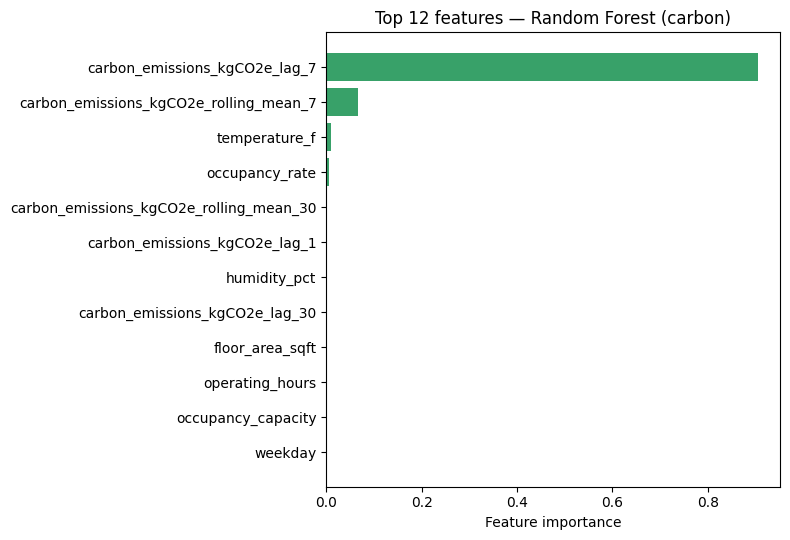

carbon_emissions_kgCO2e_lag_7              0.9058
carbon_emissions_kgCO2e_rolling_mean_7     0.0674
temperature_f                              0.0098
occupancy_rate                             0.0048
carbon_emissions_kgCO2e_rolling_mean_30    0.0019
carbon_emissions_kgCO2e_lag_1              0.0018
humidity_pct                               0.0017
carbon_emissions_kgCO2e_lag_30             0.0011
floor_area_sqft                            0.0010
operating_hours                            0.0006
occupancy_capacity                         0.0006
weekday                                    0.0006
dtype: float64


In [5]:
if hasattr(best_model, "feature_importances_"):
    importance = pd.Series(best_model.feature_importances_, index=FEATURE_COLS).sort_values(ascending=False).head(12)
    ylabel = "Feature importance"
else:
    importance = pd.Series(np.abs(best_model.coef_), index=FEATURE_COLS).sort_values(ascending=False).head(12)
    ylabel = "|Coefficient|"

fig, ax = plt.subplots(figsize=(8, 5.5))
ax.barh(importance.index, importance.values, color="#38a169")
ax.invert_yaxis()
ax.set_xlabel(ylabel)
ax.set_title(f"Top 12 features — {best_model_name} (carbon)")
plt.tight_layout(); plt.show()
print(importance.round(4))


## Visual check + where it fails (verified, not assumed)


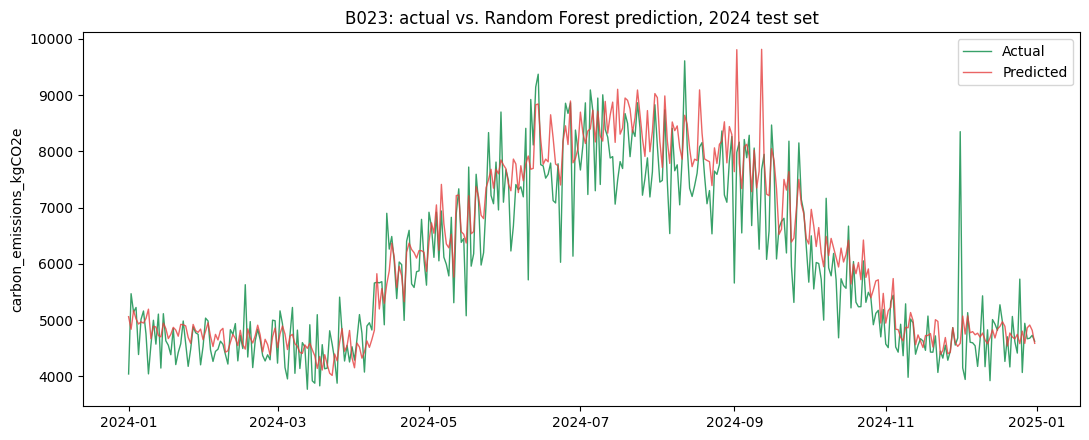

In [6]:
sample_building = "B023"  # one of the higher-emitting buildings from the EDA stage
mask = test.building_id == sample_building
plot_df = test.loc[mask, ["date"]].copy()
plot_df["actual"] = y_test[mask].values
plot_df["predicted"] = predictions[best_model_name][mask.values]
plot_df = plot_df.sort_values("date")

fig, ax = plt.subplots(figsize=(11, 4.5))
ax.plot(plot_df.date, plot_df.actual, label="Actual", lw=1, color="#38a169")
ax.plot(plot_df.date, plot_df.predicted, label="Predicted", lw=1, color="#e53e3e", alpha=0.8)
ax.set_ylabel("carbon_emissions_kgCO2e")
ax.set_title(f"{sample_building}: actual vs. {best_model_name} prediction, 2024 test set")
ax.legend()
plt.tight_layout(); plt.show()


In [7]:
test_results = test[["building_id","date"]].copy()
test_results["actual"] = y_test.values
test_results["predicted"] = predictions[best_model_name]
test_results["abs_error"] = (test_results.actual - test_results.predicted).abs()
worst = test_results.sort_values("abs_error", ascending=False).head(10)

gt = pd.read_csv("../data/processed/_validation_only_injected_anomalies.csv", parse_dates=["date"])
gt_check = worst[["building_id","date"]].merge(gt[["building_id","date"]].assign(is_true_anomaly=True), on=["building_id","date"], how="left")
gt_check["is_true_anomaly"] = gt_check["is_true_anomaly"].fillna(False)

print("10 worst-predicted building-days (carbon):")
print(worst.to_string(index=False))
print(f"\n{int(gt_check.is_true_anomaly.sum())}/10 match a genuine injected anomaly -- consistent with Model 1's finding: ")
print("this model also struggles on the same atypical days, because a spike in electricity/gas use (the anomaly)")
print("propagates directly into a spike in the carbon this model is trying to predict from operational features alone.")


10 worst-predicted building-days (carbon):
building_id       date      actual   predicted   abs_error
       B049 2024-04-04 12895.35336 5541.928245 7353.425115
       B020 2024-09-27  9933.64686 3621.135826 6312.511034
       B014 2024-11-15 10646.88200 4451.403539 6195.478461
       B023 2024-12-01  8351.53175 4586.610633 3764.921117
       B030 2024-09-20  5726.15911 2264.669967 3461.489143
       B049 2024-12-28  9931.66099 6853.776685 3077.884305
       B018 2024-11-01  5033.00729 2131.473333 2901.533957
       B015 2024-05-27  5067.26106 2190.748906 2876.512154
       B049 2024-07-21  4969.79213 7799.100582 2829.308452
       B037 2024-07-08  6452.16541 9269.560204 2817.394794

8/10 match a genuine injected anomaly -- consistent with Model 1's finding: 
this model also struggles on the same atypical days, because a spike in electricity/gas use (the anomaly)
propagates directly into a spike in the carbon this model is trying to predict from operational features alone.


## Save


In [8]:
import joblib, json as jsonlib

joblib.dump(best_model, "../models/carbon_emissions_model.joblib")
with open("../models/carbon_emissions_model_features.json", "w") as f:
    jsonlib.dump(FEATURE_COLS, f, indent=2)
results_df.to_csv("../reports/carbon_emissions_model_comparison.csv", index=False)
print(f"Saved {best_model_name} to models/carbon_emissions_model.joblib")


Saved Random Forest to models/carbon_emissions_model.joblib


## Summary

Real metrics are in the model comparison cell above and in
`reports/carbon_emissions_model_comparison.csv` — not restated here from
memory. Same limitations apply as Model 1 (observed-not-forecast weather,
no hyperparameter search, single chronological split), plus one specific
to this model: because carbon is mechanically close to a linear function
of energy volume, a large part of what this model is "learning" is
really re-deriving Model 1's problem one level removed — that's expected
and is exactly why the two models' feature-importance rankings look
structurally similar (lag/rolling of the target dominates both).

**Next stage:** `06_anomaly_detection.ipynb` — Isolation Forest, using
weather + occupancy context that the Stage 2 z-score flag couldn't see,
evaluated against the same held-out ground-truth anomalies referenced in
both models above.
